In [1]:
from data_loading import Shapes3DDataset
from torch.utils.data import DataLoader 

BATCH_SIZE=128

dataset=Shapes3DDataset(chunk_size=1024)
data_loader=DataLoader(dataset,batch_size=BATCH_SIZE,pin_memory=True,num_workers=2)

Dataset inizializzato: 480000 immagini totali. Chunk size: 1024


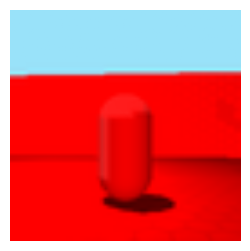

Addestramento avviato su: cuda


Epoch:1/10:   0%|                   | 2/3750 [00:05<2:17:35,  2.20s/it, Tot_loss=4.02e+3, Rec_loss=4.01e+3, KL_div=3.7]

In [ ]:
from models import VAE
from utility_functions import show_image
from torch import optim
from train_functions import train_vae,loss_function
import torch 

LR_RATE=1e-4
N_EPOCHS=10
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
TEST_IMAGE=next(iter(data_loader))[0]

show_image(TEST_IMAGE)

model=VAE(6)
optimizer=optim.Adam(model.parameters(),lr=LR_RATE)

train_vae(model=model,data_loader=data_loader,optimizer=optimizer,criterion=loss_function,n_epochs=N_EPOCHS,device=DEVICE,print_results=True,time_print=1,test_image=TEST_IMAGE)